<a href="https://colab.research.google.com/github/JosephMacula/math_and_AI_seminar/blob/main/llm_project/llm_proj_step1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget -q https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

In [ ]:
with open('input.txt', 'r') as f:   # open the downloaded file for reading, temporarily named f
    text = f.read()                 # read the whole file into one big string
print(len(text))        # how many characters long the text is: 1,115,394
print(text[:250])       # show the first 250 characters, as a sanity check

1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



In [ ]:
vocab = sorted(set(text))                     # the 65 distinct characters that occur in text, in order
V = len(vocab)                                # how many distinct characters there are: 65
stoi = {ch: i for i, ch in enumerate(vocab)}  # table: character -> its integer id
itos = {i: ch for i, ch in enumerate(vocab)}  # table: integer id -> character (the reverse)
encode = lambda s: [stoi[c] for c in s]       # turn a string into a list of integer ids
decode = lambda ids: ''.join(itos[i] for i in ids)  # turn a list of integer ids back into a string
assert decode(encode("Fear no more")) == "Fear no more"  # check: decoding an encoded string gives back the original

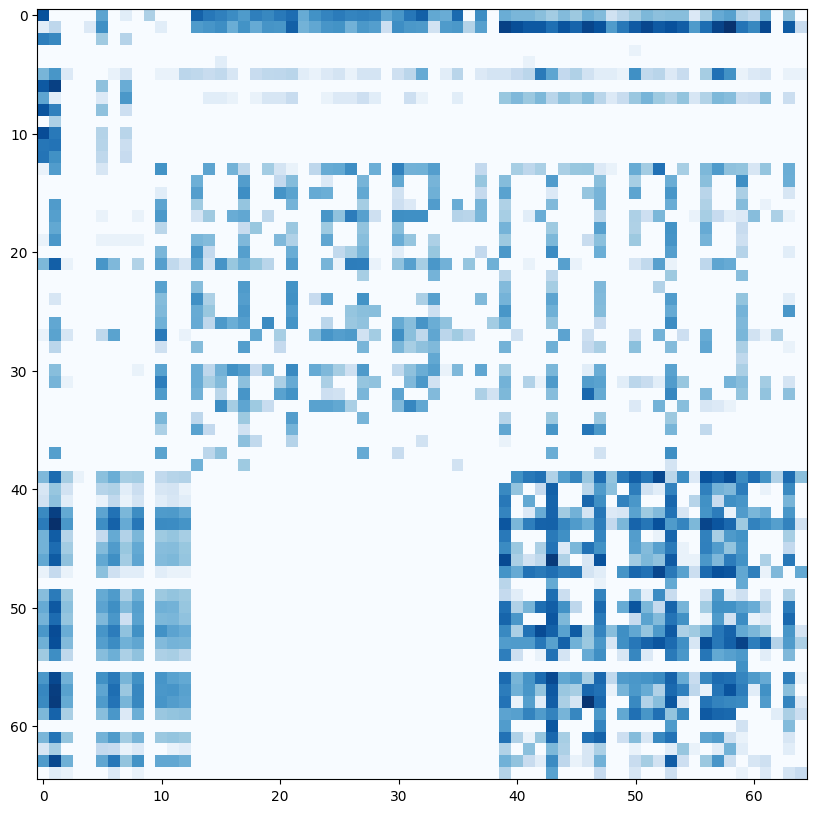

In [ ]:
import torch
import matplotlib.pyplot as plt

N = torch.zeros((V, V), dtype=torch.int64)  # a 65x65 grid of zeros, to hold the counts
ids = encode(text)               # the whole text as a list of integer ids
for a, b in zip(ids, ids[1:]):   # walk every adjacent pair of characters in the text
    N[a, b] += 1                 # add 1 to the count for "b follows a"

plt.figure(figsize=(10, 10))          # start a new 10x10-inch plot, big enough to read
plt.imshow(N.log1p(), cmap='Blues')   # draw N as an image, log-compressed so it isn't a few bright dots

In [ ]:
P = (N + 1).float()                 # add 1 to every count (smoothing), then convert to decimals
P = P / P.sum(dim=1, keepdim=True)  # divide each row by its own total, so rows become probabilities
assert torch.allclose(P.sum(dim=1), torch.ones(V))  # check: every row now sums to (approximately) 1

In [ ]:
char_idx = 0
output_text = []
for _ in range(500):
  char_idx = torch.multinomial(P[char_idx], 1).item()
  output_text.append(char_idx)
print(decode(output_text))

Bull foth r, are;
NVONGennfu masly, ived t s?
CA:
Aterg!
CI fos wie chary, ongay r RI:
SI linck,

Fon is t then re my VII:
Nof, o ofit llds fo undink n hous, gu whe, se tote nas my m ad it mpoy nvil tle if Bured,

d Whee pisot ivather to rsthine bucerest DO:
Ifimoathexasothesurafo is athelly hul w,
MI sewin ten,
I: whout ld I s wome:
WAntscoupowe gthe an's,
Whe mbens ton rcoare:
IOFofofofarthe! ur pa ting s be doul cand th I be me:
O,
H: su ave gin S ays Fre wnondied; hayse n:
Whe my ty, RThe s 


In [ ]:
ids_t = torch.tensor(ids)         # convert the list of ids into a tensor
p_next = P[ids_t[:-1], ids_t[1:]] # for every adjacent pair, look up the probability the model gave it — all at once

In [ ]:
import math


ids_t = torch.tensor(ids)               # the whole encoded text as one tensor, so it can be used as an index

def avg_log_loss(P, ids_t):
    p_next = P[ids_t[:-1], ids_t[1:]]   # entry t is P[ids[t], ids[t+1]]: the probability the model gave to what came next
    return float(-torch.log(p_next).mean())   # L = average of -log of those, in nats

def report(name, L):                    # one loss, printed three equivalent ways
    print(f'{name:<18} {L:.4f} nats   {L / math.log(2):.4f} bits/char   '   # nats; divide by ln 2 for bits per character
          f'perplexity {math.exp(L):.3f}')                                  # and e^L for perplexity

P_uniform = torch.full((V, V), 1 / V)   # the baseline, through the same code

report('bigram (add-one)', avg_log_loss(P, ids_t))   # the fitted model
report('uniform', avg_log_loss(P_uniform, ids_t))    # the model that has learned nothing: L should be ln 65

bigram (add-one)   2.4549 nats   3.5417 bits/char   perplexity 11.646
uniform            4.1744 nats   6.0224 bits/char   perplexity 65.000


In [ ]:
n_train = int(0.9 * len(ids))         # the index that's 90% of the way through the text
ids_tr = torch.tensor(ids[:n_train])  # the first 90% of the ids: the training set
ids_va = torch.tensor(ids[n_train:])  # the last 10% of the ids: the validation set

In [ ]:
N_tr = torch.zeros((V, V), dtype=torch.int64)  # a 65x65 grid of zeros, to hold the counts
ids_tr = encode(text)               # the whole text as a list of integer ids
for a, b in zip(ids_tr, ids_tr[1:]):   # walk every adjacent pair of characters in the text
    N_tr[a, b] += 1                 # add 1 to the count for "b follows a"

# plt.figure(figsize=(10, 10))          # start a new 10x10-inch plot, big enough to read
# plt.imshow(N.log1p(), cmap='Blues')   # draw N as an image, log-compressed so it isn't a few bright dots

In [ ]:
P_tr = (N_tr + 1).float()                 # add 1 to every count (smoothing), then convert to decimals
P_tr = P_tr / P_tr.sum(dim=1, keepdim=True)  # divide each row by its own total, so rows become probabilities
assert torch.allclose(P_tr.sum(dim=1), torch.ones(V))  # check: every row now sums to (approximately) 1

In [ ]:
report('bigram (add-one)', avg_log_loss(P_tr, ids_tr))
report('bigram (add-one)', avg_log_loss(P_tr, ids_va))

bigram (add-one)   2.4549 nats   3.5417 bits/char   perplexity 11.646
bigram (add-one)   2.4471 nats   3.5304 bits/char   perplexity 11.554


In [ ]:
train_count_of_val_pairs = N_tr[ids_va[:-1], ids_va[1:]]  # for every validation-set pair, how many times training saw it
print((train_count_of_val_pairs == 0).sum())              # how many of those pairs training never saw at all

tensor(0)


In [ ]:
report('uniform', avg_log_loss(P_uniform, ids_va))

uniform            4.1744 nats   6.0224 bits/char   perplexity 65.000
